# <font color='blue'>Trabalho Prático 2 - Planejamento e Navegação</font>
# <font color='blue'>Passo 1a: Roadmaps PRM - Robotino</font>

### <font color='blue'>Weber Vieira de Souza</font>
### <font color='blue'>2025719242</font>

## Instalando e Carregando os Pacotes

In [23]:
# Versão da Linguagem Python
from platform import python_version
print('Versão da Linguagem Python Usada Neste Jupyter Notebook:', python_version())

Versão da Linguagem Python Usada Neste Jupyter Notebook: 3.11.5


In [ ]:
# Instala o pacote watermark. 
# Esse pacote é usado para gravar as versões de outros pacotes usados neste jupyter notebook.
%pip install -q -U watermark

In [ ]:
# https://pypi.org/project/gradio/
# https://pypi.org/project/Shapely/
# pip install -q shapely
# conda install --channel conda-forge shapely
# pip install -q descartes
%pip install -q numpy shapely networkx scipy matplotlib random descartes coppeliasim-zmqremoteapi-client

In [24]:
# Imports
import random
import time; import math
import heapq
try:
    import sim
except:
    print ('----------"sim.py" could not be imported----------------------')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import networkx as nx
from PIL import Image
from coppeliasim_zmqremoteapi_client import RemoteAPIClient

from collections import deque
from scipy.spatial import KDTree, distance

In [25]:
# Versões dos pacotes usados neste jupyter notebook
%reload_ext watermark
%watermark -a "Weber Souza" --iversions

Author: Weber Souza

coppeliasim_zmqremoteapi_client: 2.0.4
numpy                          : 1.24.3
networkx                       : 3.1
scipy                          : 1.11.1
matplotlib                     : 3.7.2
PIL                            : 9.4.0
platform                       : 1.0.8



In [26]:
# Conecta com o CoppeliaSim
client = RemoteAPIClient()
sim = client.require("sim")
sim.setStepping(True)

0

In [27]:
def load_occupancy(path, thr=200):
    img = Image.open(path).convert('L')
    occ = np.array(img)
    occ = (occ < thr).astype(np.uint8)  # 1=obstáculo, 0=livre
    return occ

In [ ]:
# Verifica se o caminho entre dois pontos está livre de colisões.
def collision_free(p, q, occ):
    p, q = np.array(p, float), np.array(q, float)
    n = int(np.linalg.norm(q-p))+1
    for t in np.linspace(0,1,n):
        x,y = (p + t*(q-p)).astype(int)
        if x<0 or y<0 or x>=occ.shape[1] or y>=occ.shape[0] or occ[y,x]==1:
            return False
    return True

In [48]:
# Gerando amostras aleatóras
def samples(num, occ):
    h,w = occ.shape
    samples = []
    count = 0
    while len(samples)<num and count<10*num:
        x,y = np.random.randint(0,w), np.random.randint(0,h)
        if occ[y,x]==0:
            samples.append((x,y))
        count+=1
    return np.array(samples)

In [49]:
# Construir roadmap
def build_prm(occ, n_samples=800, k=12):
    pts = samples(n_samples, occ)
    tree = KDTree(pts)
    edges = [[] for _ in range(len(pts))]
    for i,p in enumerate(pts):
        d, idxs = tree.query(p, k+1)
        for j in idxs[1:]:
            q = pts[j]
            if collision_free(p, q, occ):
                edges[i].append(j)
                edges[j].append(i)
    return pts, edges

In [ ]:
# Encontra o caminho mais curto no grafo usando Probabilistic Roadmap
def shortest_path(pts, edges, s, g):
    n = len(pts)
    dist = np.full(n, np.inf)
    prev = np.full(n, -1, dtype=int)
    dist[s]=0.0
    pq=[(0.0, s)]
    while pq:
        d,u=heapq.heappop(pq)
        if d>dist[u]: continue
        if u==g: break
        for v in edges[u]:
            w = np.linalg.norm(pts[u]-pts[v])
            nd = d + w
            if nd<dist[v]:
                dist[v]=nd; prev[v]=u; heapq.heappush(pq,(nd,v))
    if not np.isfinite(dist[g]): return None, np.inf
    path=[g]
    while path[-1]!=s:
        path.append(prev[path[-1]])
    path=path[::-1]
    return path, dist[g]

In [50]:
def nearest_node(pts, x):
    d = np.linalg.norm(pts - x, axis=1)
    return np.argmin(d)

In [51]:
def run_experiment(path_img, start, goal, prm_params):
    occ = load_occupancy(path_img)
    pts, edges = build_prm(occ, **prm_params)
    s_idx = nearest_node(pts, np.array(start))
    g_idx = nearest_node(pts, np.array(goal))
    path_idx, cost = shortest_path(pts, edges, s_idx, g_idx)
    fig, ax = plt.subplots(figsize=(5,5))
    ax.imshow(1-occ, cmap='gray', origin='upper')
    ax.scatter(pts[:,0], pts[:,1], s=3)
    ax.scatter([start[0], goal[0]],[start[1], goal[1]], s=20)
    if path_idx is not None:
        P = pts[path_idx]
        ax.plot(P[:,0], P[:,1])
    ax.set_xticks([]); ax.set_yticks([])
    plt.show()
    return P,cost

### Experimento 1: Mapa 1 - Cenário Simples

[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [

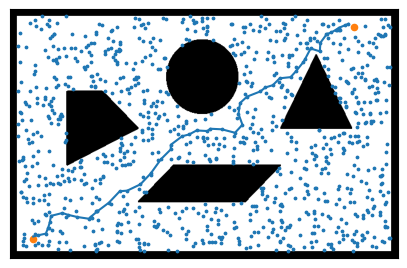

Caminho encontrado com comprimento: 11.22 m
Simulação Parada


In [52]:
# Simulacao
sim.startSimulation()
try:
    start = (40,400)
    goal = (600,30)
    p1,cost1 = run_experiment("Imagens/mapa1_invertido.png", start=(40,400), goal=(600,30),
                       prm_params=dict(n_samples=1000, k=5))
    print(f"Caminho encontrado com comprimento: {cost1*0.014792899:.2f} m")
except Exception as e:
    print(f"An error occurred: {e}")
    
sim.stopSimulation()
print('Simulação Parada')

### Experimento 1: Robot Holonômico - Robotino

In [35]:
# Matriz de rotação em relação a Z
def Rz(theta):
  
    return np.array([[ np.cos(theta), -np.sin(theta), 0 ],
                      [ np.sin(theta), np.cos(theta) , 0 ],
                      [ 0            , 0             , 1 ]])

In [ ]:
# Simulacao
sim.startSimulation()
try:
    # Handle para o ROBÔ
    robotname = 'robotino'
    robotHandle = sim.getObject('/' + robotname)
    
    # Handle para as juntas das RODAS
    wheel0 = sim.getObject('/wheel0_joint')
    wheel1 = sim.getObject('/wheel1_joint')
    wheel2 = sim.getObject('/wheel2_joint')

    # Dados Robotino
    L = 0.135   # Metros
    r = 0.040   # Metros  
    
    # Cinemática Direta
    Mdir = np.array([[-r/np.sqrt(3), 0, r/np.sqrt(3)], [r/3, (-2*r)/3, r/3], [r/(3*L), r/(3*L), r/(3*L)]])
   
    # Lembrar de habilitar o 'Real-time mode'    
    # Parar a simulação se estiver executando
    initial_sim_state = sim.getSimulationState()
    if initial_sim_state != 0:
        sim.stopSimulation()
        time.sleep(1)
    
    # Inicia a simulação
    sim.startSimulation()
    sim.step()

    # Frame que representa o Goal
    goalFrame = sim.getObject('/Goal')
    sim.setObjectPosition(goalFrame, [goal[0], goal[1], 0], sim.handle_world)
    sim.setObjectOrientation(goalFrame, [0, 0, goal[1]], sim.handle_world)
    
    # Caminho do PRM — convertendo coordenadas de pixels para metros 
    scale = 0.014792899  # 1 pixel = 1.47 cm
    path = np.array(p1, dtype=float) * scale

    gain = np.array([[0.1, 0, 0], [0, 0.1, 0], [0, 0, 0.1]])
    #gain = np.array([[0.3, 0, 0], [0, 0.1, 0], [0, 0, 0.1]])
    
    print("Starting robot control loop...")
    for wp in path:
        qgoal = np.array([wp[0], wp[1], 0.0])
        # while (sim_time := sim.getSimulationTime()) <= 90:
        #     print(f"Simulation time: {sim_time:.2f} [s]")
        dt = sim.getSimulationTimeStep()
                
        pos = sim.getObjectPosition(robotHandle, sim.handle_world)
        ori = sim.getObjectOrientation(robotHandle, sim.handle_world)

        q = np.array([pos[0], pos[1], ori[2]])
        
        error = qgoal - q
        print(f"Error: {np.linalg.norm(error[:2])}")
        
        # Margem aceitável de distância
        if (np.linalg.norm(error[:2]) < 0.05):
            break

        # Controller
        qdot = gain @ error
        
        # Cinemática Inversa
        # w1, w2, w3
        Minv = np.linalg.inv(Rz(q[2]) @ Mdir)
        u = Minv @ qdot
        
        # Enviando velocidades
        sim.setJointTargetVelocity(wheel0, u[0])
        sim.setJointTargetVelocity(wheel1, u[1])
        sim.setJointTargetVelocity(wheel2, u[2]) 
                
        sim.step()

    # Parando o robô
    print("Stopping robot...")
    sim.setJointTargetVelocity(wheel0, 0)
    sim.setJointTargetVelocity(wheel1, 0)
    sim.setJointTargetVelocity(wheel2, 0)
    
except Exception as e:
    print(f"An error occurred: {e}")
sim.stopSimulation()
print('Program ended')

### Experimento 2: Mapa 2 - Cenário Complexo

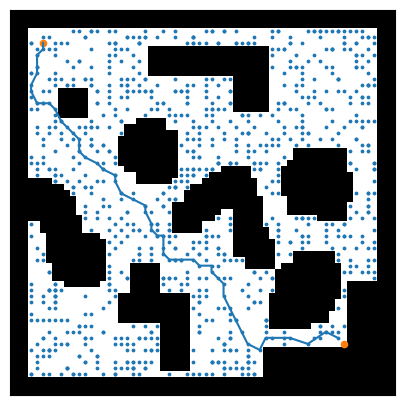

Caminho encontrado com comprimento: 13.83 m
Simulação Parada


In [46]:
# Simulacao
sim.startSimulation()
try:
    p2,cost2 = run_experiment("Imagens/mapa2_invertido.png", start=(5,5), goal=(55,55),
                       prm_params=dict(n_samples=1000, k=5))
    print(f"Caminho encontrado com comprimento: {cost2*0.15625:.2f} m")
except Exception as e:
    print(f"An error occurred: {e}")
    
sim.stopSimulation()
print('Simulação Parada')

### Experimento 2: Robot Holonômico - Robotino

In [ ]:
# Simulacao
sim.startSimulation()
try:
    # Handle para o ROBÔ
    robotname = 'robotino'
    robotHandle = sim.getObject('/' + robotname)
    
    # Handle para as juntas das RODAS
    wheel0 = sim.getObject('/wheel0_joint')
    wheel1 = sim.getObject('/wheel1_joint')
    wheel2 = sim.getObject('/wheel2_joint')
              
    # Dados Robotino
    L = 0.135   # Metros
    r = 0.040   # Metros  
    
    # Cinemática Direta
    Mdir = np.array([[-r/np.sqrt(3), 0, r/np.sqrt(3)], [r/3, (-2*r)/3, r/3], [r/(3*L), r/(3*L), r/(3*L)]])
           
    # Goal configuration (x, y, theta)    
    qgoal = np.array([3, 3, np.deg2rad(90)])
    #qgoal = np.array([3, -3, np.deg2rad(-90)])
    #qgoal = np.array([0, 0, np.deg2rad(0)])
    
    # Lembrar de habilitar o 'Real-time mode'    
    # Parar a simulação se estiver executando
    initial_sim_state = sim.getSimulationState()
    if initial_sim_state != 0:
        sim.stopSimulation()
        time.sleep(1)
    
    # Inicia a simulação
    sim.startSimulation()
    sim.step()

    # Frame que representa o Goal
    goalFrame = sim.getObject('/Goal')
    sim.setObjectPosition(goalFrame, [qgoal[0], qgoal[1], 0], sim.handle_world)
    sim.setObjectOrientation(goalFrame, [0, 0, qgoal[2]], sim.handle_world)
    
    # Caminho do PRM — convertendo coordenadas de pixels para metros 
    scale2 = 0.15625  # 1 pixel = 15.625 cm
    path2 = p2 * scale

    gain = np.array([[0.1, 0, 0], [0, 0.1, 0], [0, 0, 0.1]])
    #gain = np.array([[0.3, 0, 0], [0, 0.1, 0], [0, 0, 0.1]])
    
    print("Starting robot control loop...")
    for wp in path:
        qgoal = np.array([wp[0], wp[1], 0.0])
        # while (sim_time := sim.getSimulationTime()) <= 90:
        #     print(f"Simulation time: {sim_time:.2f} [s]")
        dt = sim.getSimulationTimeStep()
                
        pos = sim.getObjectPosition(robotHandle, sim.handle_world)
        ori = sim.getObjectOrientation(robotHandle, sim.handle_world)

        q = np.array([pos[0], pos[1], ori[2]])
        
        error = qgoal - q
        print(f"Error: {np.linalg.norm(error[:2])}")
        
        # Margem aceitável de distância
        if (np.linalg.norm(error[:2]) < 0.05): # pixels
            break

        # Controller
        qdot = gain @ error
        
        # Cinemática Inversa
        # w1, w2, w3
        Minv = np.linalg.inv(Rz(q[2]) @ Mdir)
        u = Minv @ qdot
        
        # Enviando velocidades
        sim.setJointTargetVelocity(wheel0, u[0])
        sim.setJointTargetVelocity(wheel1, u[1])
        sim.setJointTargetVelocity(wheel2, u[2]) 
                
        sim.step()

    # Parando o robô
    print("Stopping robot...")
    sim.setJointTargetVelocity(wheel0, 0)
    sim.setJointTargetVelocity(wheel1, 0)
    sim.setJointTargetVelocity(wheel2, 0)
    
except Exception as e:
    print(f"An error occurred: {e}")
sim.stopSimulation()
print('Program ended')

# Fim